# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = ('/content/drive/MyDrive/Data Analyst/Python/Data/yulu_rental.csv')
df = pd.read_csv('/content/drive/MyDrive/Data Analyst/Python/Data/yulu_rental.csv')

df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

In [ ]:
# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [ ]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

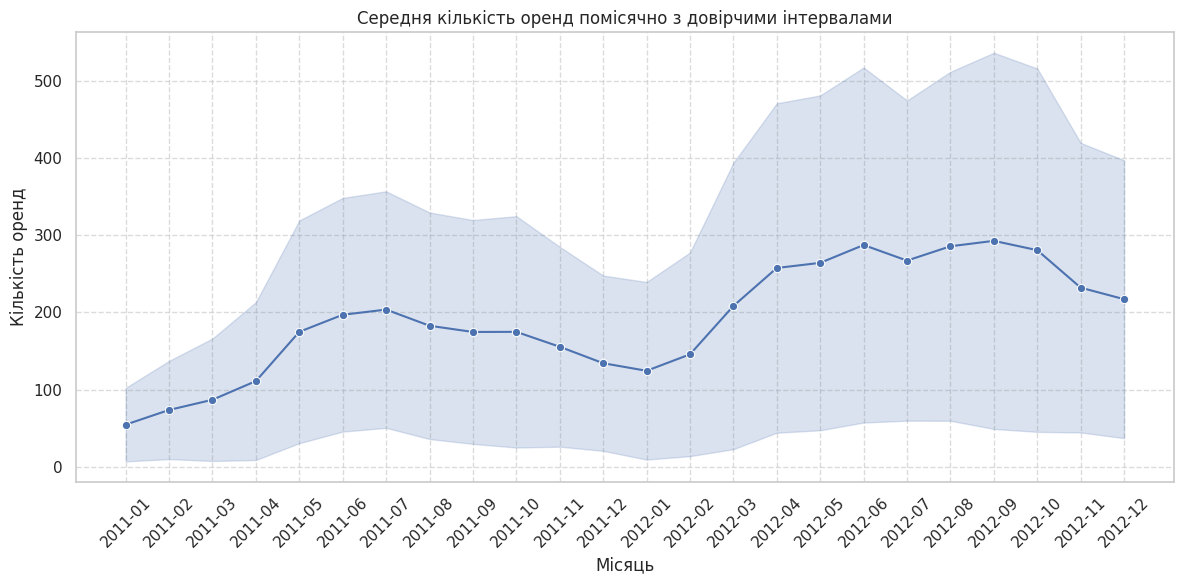

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    df,
    x='month_year',
    y='count',
    marker='o',
    errorbar=('sd', 1)
)

plt.title('Середня кількість оренд помісячно з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренд')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.7, linestyle='--')
plt.tight_layout()

plt.show()

1. Найбільша невизначеність даних припадає на літні та ранньоосінні місяці 2012 року (червень, серпень - вересень, жовтень).

Це зумовлено піковим попитом у літньо-осінній період 2012 року. У ці місяці на розкид даних впливає багато факторів: день тижня, погодні умови, наявність свят. Натомість у періоди низького попиту дані стабільніші та концентруються навколо менших значень.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

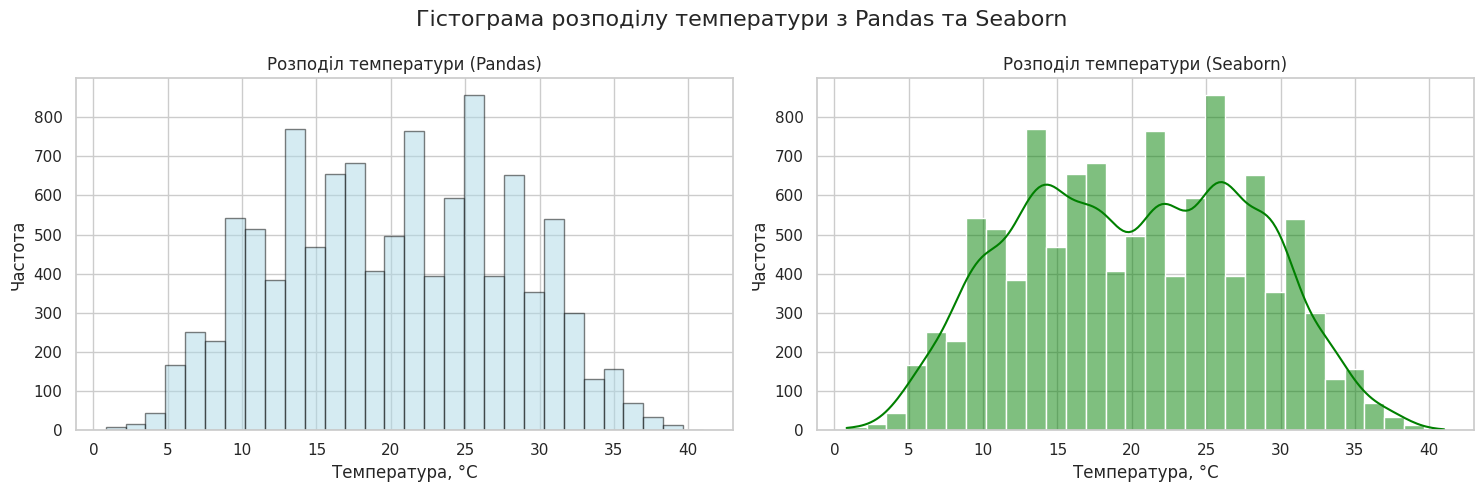

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df['temp'].plot.hist(
    bins=30,
    alpha=0.5,
    ax=axes[0],
    color='lightblue',
    edgecolor='black',
    title='Розподіл температури (Pandas)',
    xlabel='Температура, °C',
    ylabel='Частота'
)

sns.histplot(df['temp'],
    bins=30,
    kde=True,
    ax=axes[1],
    color='green'
)

axes[1].set_title('Розподіл температури (Seaborn)')
axes[1].set_xlabel('Температура, °C')
axes[1].set_ylabel('Частота')

fig.suptitle("Гістограма розподілу температури з Pandas та Seaborn", fontsize=16)
plt.tight_layout()
plt.show()

1. Pandas призначений для швидкого EDA і створює базову гістограму без додаткових статистичних елементів — це зручно для первинного огляду даних, але обмежене в аналітичних можливостях. Seaborn — автоматично додає KDE-криву для оцінки щільності, має вбудовані естетичні налаштування (кольорові палітри, шрифти, відступи) та дозволяє легко сегментувати дані за групами через параметр hue.

2. KDE-крива (Kernel Density Estimate) це — згладжена оцінка щільності розподілу, яка показує ймовірність появи значень на різних ділянках шкали. На відміну від гістограми, де форма розподілу залежить від вибору кількості бінів, KDE дає плавну криву, яка чіткіше виявляє структуру даних — нормальність розподілу, асиметрію, наявність кількох піків (мультимодальність).

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

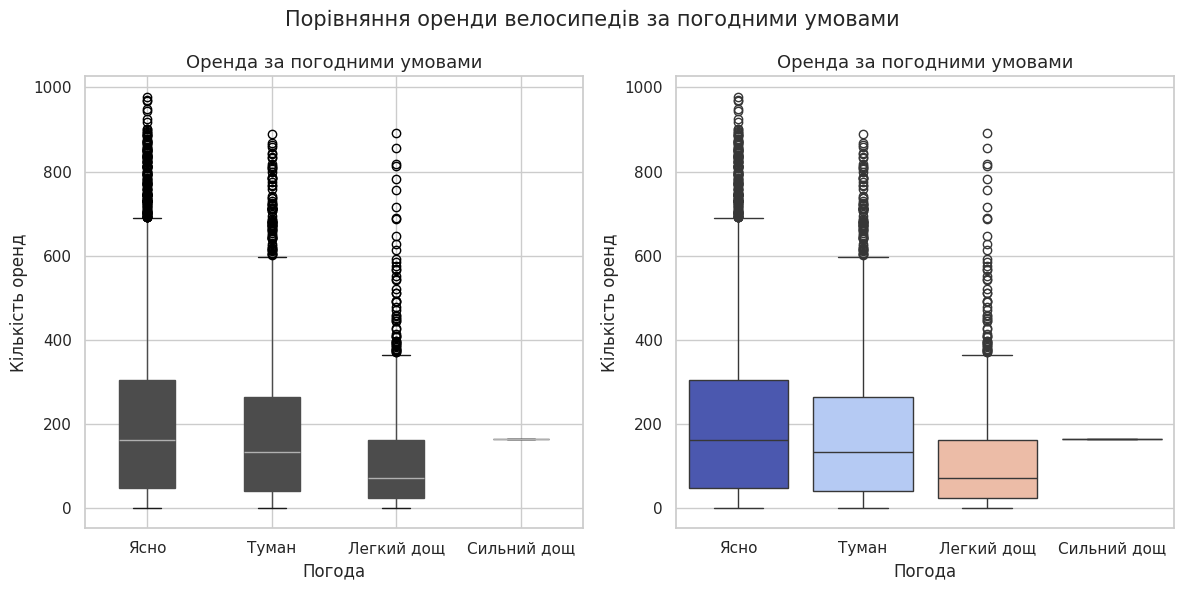

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

df.boxplot(
    column='count',
    by='weather',
    ax=axes[0],
    patch_artist=True
)

plt.suptitle('')

axes[0].set_title('Оренда за погодними умовами', fontsize=13)
axes[0].set_xlabel('Погода', fontsize=12)
axes[0].set_ylabel('Кількість оренд', fontsize=12)
axes[0].set_xticks([1, 2, 3, 4])
axes[0].set_xticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])

sns.boxplot(
    data=df,
    x='weather',
    y='count',
    hue='weather',
    legend=False,
    ax=axes[1],
    palette='coolwarm'
)

axes[1].set_title('Оренда за погодними умовами', fontsize=13)
axes[1].set_xlabel('Погода', fontsize=12)
axes[1].set_ylabel('Кількість оренд', fontsize=12)
axes[1].set_xticks([0, 1, 2, 3])
axes[1].set_xticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])

plt.suptitle('Порівняння оренди велосипедів за погодними умовами', fontsize=15)
plt.tight_layout()
plt.show()

1. Pandas потребує ручного налаштування підписів осей (set_xticklabels), порядку категорій та кольорів, що робить код довшим. Seaborn автоматично використовує назви з DataFrame, підтримує логічний порядок категорій, має вбудовані палітри та кольорове кодування через hue, забезпечуючи кращу естетику з меншою кількістю коду.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [ ]:
correlation = df[["temp", "atemp", "humidity", "windspeed", "casual", "registered", "count"]].corr()
correlation

,temp,atemp,humidity,windspeed,casual,registered,count
temp,1.000000,0.984948,-0.064949,-0.017852,0.467097,0.318571,0.394454
atemp,0.984948,1.000000,-0.043536,-0.057473,0.462067,0.314635,0.389784
humidity,-0.064949,-0.043536,1.000000,-0.318607,-0.348187,-0.265458,-0.317371
windspeed,-0.017852,-0.057473,-0.318607,1.000000,0.092276,0.091052,0.101369
casual,0.467097,0.462067,-0.348187,0.092276,1.000000,0.497250,0.690414
registered,0.318571,0.314635,-0.265458,0.091052,0.497250,1.000000,0.970948
count,0.394454,0.389784,-0.317371,0.101369,0.690414,0.970948,1.000000


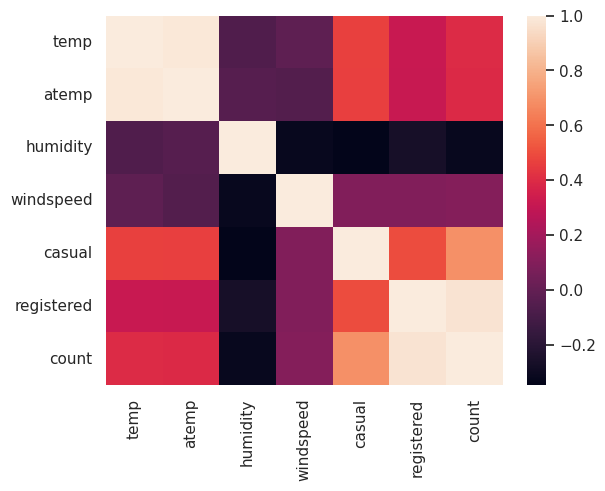

In [ ]:
sns.heatmap(correlation);

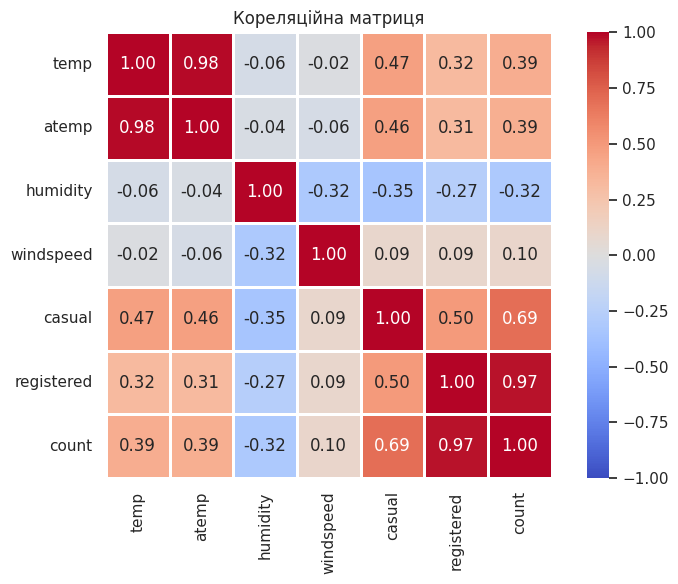

In [ ]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1
)

plt.title("Кореляційна матриця")
plt.tight_layout()
plt.show()

1. Найсильніший кореляціний зв'язок із загально кількостю оренд (count) - між count та registered (0.97). Також можна відмітити кореляційний звʼязок з casual (0.69), що є цілком логічним, адже registered + casual = count.
2. Змінні temp та atemp мають дуже високий кореляційний звʼязок (0.98), адже ці показники майже однакові.
3. Немагативний кореляційний звʼязок мають дві змінні humidity та windspeed. Humidity має негативну кореляцію з усіма показниками. Найбільше відʼмне значення із casual (-0.35), (count, windspeed = (-0.32)). Windspeed має дуже відʼмну кореляцію з temp (-0.02) та atemp (-0.06).

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


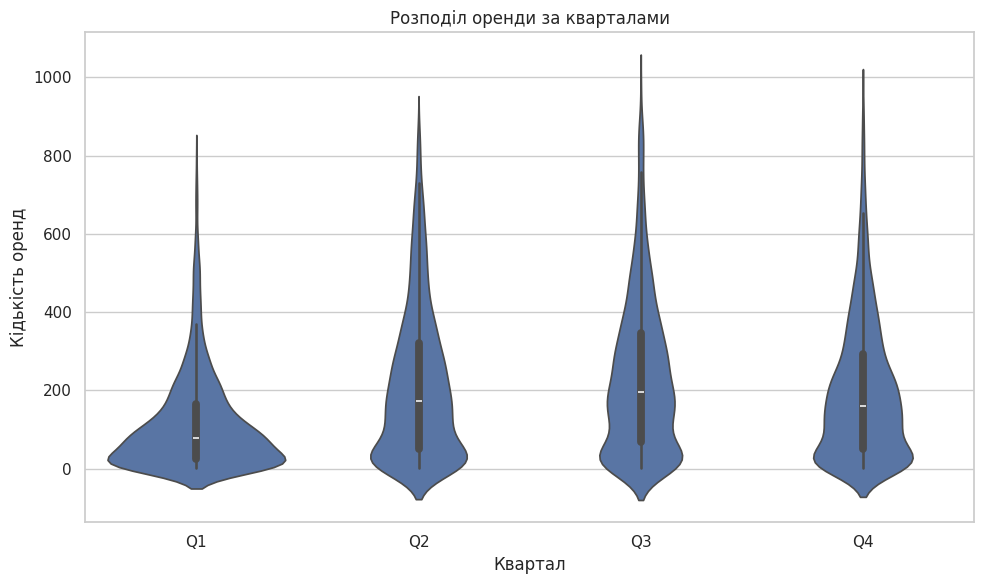

In [ ]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='season',
    y='count')

plt.title('Розподіл оренди за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кідькість оренд')
plt.xticks([0, 1, 2, 3], ['Q1', 'Q2', 'Q3', 'Q4'])

plt.tight_layout()
plt.show()

1. Товщина (ширина) violin plot показує щільність розподілу даних на кожному рівні значень. Чим ширша ділянка — тим більше записів з таким значенням оренди. Наприклад, широка середина у Q2-Q4 означає, що найчастіше оренда була в діапазоні 150-200, а вузька верхівка показує, що екстремально високі значення (900-1000) трапляються рідко.

2. Q3 має найбільшу варіабельність:
- Найширший діапазон: від ~0 до ~1050 оренд;
- Найдовша "скрипка": розподіл найбільш розтягнутий;
- Широка верхня частина: багато днів з високою орендою (600-900).

3. Violin plot показує повний розподіл даних, тоді як box plot показує лише квартилі та викиди. Violin plot виявляє форму розподілу — чи є кілька піків (мультимодальність), асиметрію, концентрацію даних — що неможливо побачити на box plot. Наприклад, на цьому графіку видно, що у Q2-Q4 є два піки (вузьке місце посередині "скрипки"), що може вказувати на різницю між вихідними та робочими днями, чого box plot не покаже.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

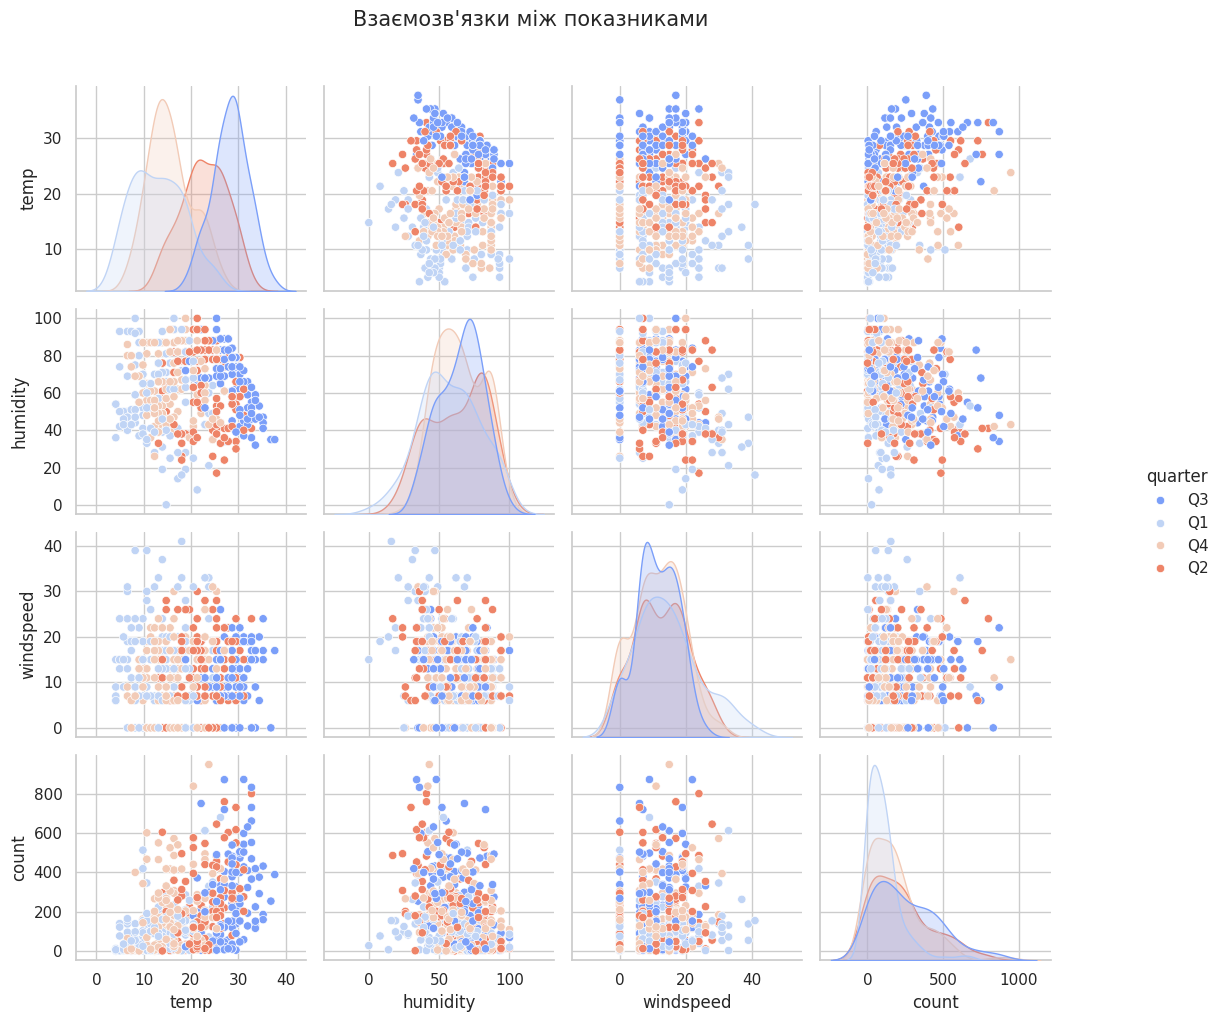

In [ ]:
indic = ["temp", "humidity", "windspeed", "count", "season"]
# виносимо показники в окрему змінну, щоб вразі змін ми могли оновити дані тільки в одному місці

sample_df = df[indic].sample(500, random_state=42).copy()
sample_df['quarter'] = sample_df['season'].map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})

g = sns.pairplot(
    sample_df.drop('season', axis=1),
    hue="quarter",
    height=2.5,
    palette='coolwarm'
)

g._legend.set_bbox_to_anchor((1.05, 0.5))  # перенесення легенди окремо праворуч
g._legend.set_loc('center left')

plt.suptitle("Взаємозв'язки між показниками", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

1. На графіку ми бачимо, що сильний лінійний зв’язок спостерігається між temp та count - зі зростанням температури зростає кількість оренд (сильна позитивна кореляція).
2. Найбільше відрізняється між кварталами температура (temp), адже ми чітко бачимо, що кольори розділяють сезони за температурою. Розбіжність 20-25°C між зимою та літом, чотири чітко розділені піки на KDE.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

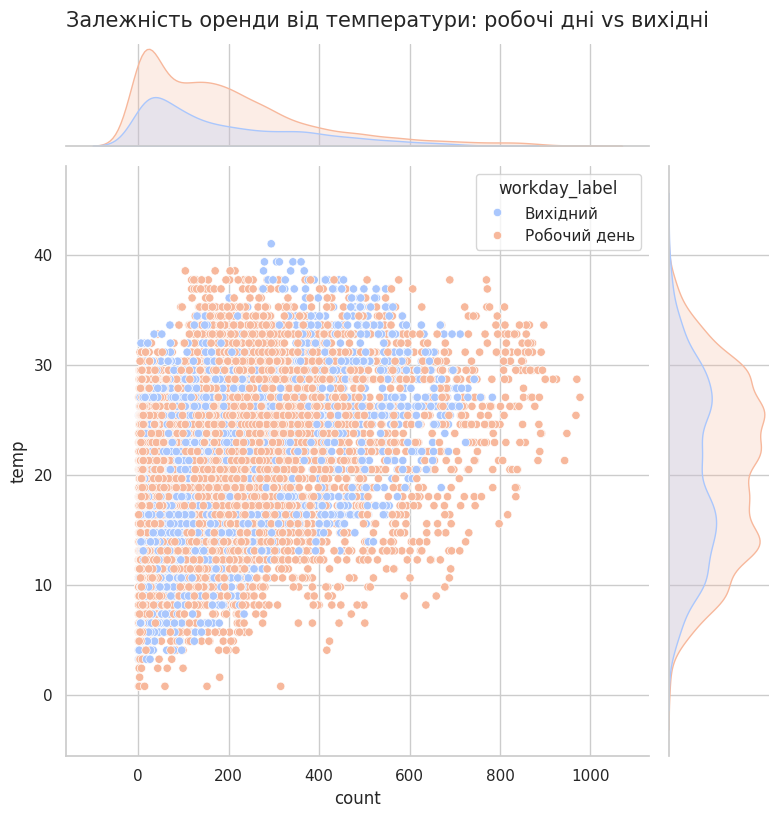

In [ ]:
work_map = {0: 'Вихідний', 1: 'Робочий день'}
df['workday_label'] = df['workingday'].map(work_map)

g = sns.jointplot(
    data=df,
    x='count',
    y='temp',
    hue='workday_label',
    palette='coolwarm',
    height=8
)

g.fig.suptitle('Залежність оренди від температури: робочі дні vs вихідні', y=1.02, fontsize=15)
plt.show()

1. Що показують графіки по краях:
- Верхній: розподіл кількості оренд. Робочі дні мають вищий, вихідні менший.
- Правий: розподіл температури (ідентичний для обох груп — температура не залежить від дня тижня)
2. У робочі дні значно більше оренд, бо активні зареєстровані комьютери. Температура впливає однаково на обидві групи, але при однаковій температурі робочі дні генерують більший попит.